<a href="https://colab.research.google.com/github/maureen-zhang/qiskit-subset-sum/blob/main/SUBSET_SUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What needs
to be written in this document:

**Clear all the veraible and notation , so the code is easto read. **
** each functon deserve one block **


Q whats the largest valiue needed for the sum
https://arxiv.org/pdf/2410.01775


  Circuits to buit(functions to call):
* H-gate
* adder

---

* documentation for setup/notation for vanilla Grover search, including words about size of data access oracle - Silas
* efficient adder subroutine - Maureen
* marker which marks target state t - Maureen
* diffuser - Silas





# Subset-Sum Problem

**Input**: a finite list of positive integers $\{m_0, m_1, \dots, m_{n-1}\}$ and a positive integer $t$.

**Output**: a subset $I \subseteq \{0, 1, \dots, n-1\}$ such that $\sum_{i \in I} m_i = t$, or decides, with high probability, that no such subset exists.

# Solution using Grover's search algorithm

We will solve this problem using Grover's quantum search algorithm. We will implement:

- A quantum register of $n$ qubits representing bitstrings $x_0 x_1 \dots x_n$ of length $n$, which correspond to subsets $I \subseteq \{0, 1, \dots, n-1\}$.

- An ancilla register of $d$ qubits, where $d$ is a positive integer which is sufficiently large that we can represent all possible sums $\sum_{i \in I} x_i$ as binary bitstrings.

We will implement the marker oracle using adder circuits constructed by Akos Nagy.

In [2]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt

import numpy as np

## Initializing global variables

In [8]:
# M = given list of positive integers
M = np.array([1,3,5,8])

# n = number of positive integers provided
n = len(M)

# target_sum = the target sum we want to achieve by summing a subset of the integers in M
target_sum = 6

# We need to determine the number of bits needed to represent the maximum possible sum of subsets of M
max_sum = sum(M)
bits_needed = int(max_sum).bit_length()

We now initialize the quantum and ancilla registers.

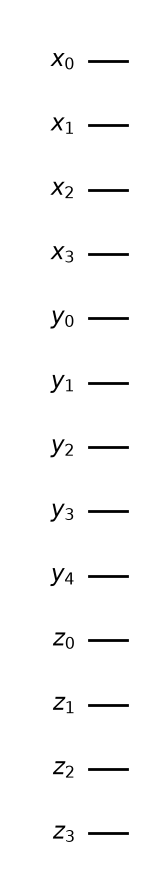

In [10]:
quantum_register = QuantumRegister(size=n, name='x')
ancilla_register = AncillaRegister(size=bits_needed, name='y')
ancilla_register2 = AncillaRegister(size=bits_needed - 1, name='z')

qc = QuantumCircuit(quantum_register, ancilla_register, ancilla_register2)
qc.draw(output="mpl")

# Adder Circuit (credit: Akos Nagy)

The first step of converting the subset-sum problem into a Grover search problem is to encode it into a function $F$.

We are given a list of positive integers $\{m_0, m_1 , \dots, m_{n-1}\}$.

Let $F: \mathbb{F}_2^n \rightarrow \mathbb{Z}$ be defined as

\begin{equation}
    F(x_0, x_1 , \dots, x_{n-1}) = m_0 x_0 + m_1 x_1 \dots + m_{n-1} x_{n-1}.
\end{equation}

Our goal is the solve the equation

\begin{equation}
    F(x_0, x_1, \dots, x_{n-1}) = t,
\end{equation}

using Grover's algorithm.

In [ ]:
# This block of code will estabilish adder

#quantum_register = QuantumRegister(size=2, name="x")
#ancilla_register = AncillaRegister(size=2, name="y")
k = the number of integers in M that we want to sum up to target_sum
d = maxicimal bits_needed to represent the maximum possible sum of subsets of M

F_adder = QuantumCircuit(quantum_register, ancilla_register, name="F(x) adder")

F_adder.cx(quantum_register[0], ancilla_register[1])
F_adder.ccx(quantum_register[1], ancilla_register[0], ancilla_register[1])
F_adder.cx(quantum_register[1], ancilla_register[0])

F_adder.draw(output="mpl")

# Marker Circuit

# Defusser Circuit
